In [10]:
#Load and inspect

from data_loader import load_data
from feature_engineering import add_engineered_features

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

#Database path
db_path = r"C:\Users\jacov\anaconda_projects\Marvel Insurance\data\superhero_events_db.duckdb"

#Load data
df = load_data(db_path)

#Feature engineering
df = add_engineered_features(df)

print("Shape:", df.shape)

print("\nMissing values:\n")
print(df.isnull().sum())

#Keep only rows with known target for EDA
df_model = df.dropna(subset=["annual_public_destruction_events"])

Shape: (91, 10)

Missing values:

index                                0
name                                 0
CreditInfo                           0
annual_public_destruction_events    21
credit_score                         1
age                                  1
num_superpowers                      0
num_properties                       0
num_credit_cards                     0
total_credit_limit                   0
dtype: int64


In [12]:
#Closer inspect missing value xml
missing = df[df["credit_score"].isnull()]

if not missing.empty:
    missing_row = missing.iloc[0]
    print("Superhero Name:", missing_row["name"])
    print("\nRaw XML:\n")
    print(missing_row["CreditInfo"])

Superhero Name: Kratos

Raw XML:

<?xml version="1.0" encoding="UTF-8" ?><superhero><Name>Kratos</Name><CreditScore>99</CreditScore><DateOfBirth>1947-11-25</DateOfBirth><SuperPowers><item>invisibility</item></SuperPowers><CreditCards><item><Bank>Roxxon Savings and Loan</Bank><CreditLimit>23443</CreditLimit><DateOpened>2017-12-17</DateOpened></item><item><Bank>Wakanda International Bank</Bank><CreditLimit>77743</CreditLimit><DateOpened>2021-03-19</DateOpened></item><item><Bank>Hellfire Club Bank</Bank><CreditLimit>78576</CreditLimit><DateOpened>2021-01-13</DateOpened></item><item><Bank>Pym Technologies Bank</Bank><CreditLimit>94977</CreditLimit><DateOpened>2017-05-05</DateOpened></item></CreditCards><PropertiesOwnedBySuperhero><item>816 Babylon Hill</item><item>924 Cair Paravel Terrace</item><item>665 Lilliput Garden</item><item>994 Vulcan Garden</item><item>975 R&#x27;lyeh Drive</item><item>783 Quirm Park</item><item>326 Themyscira Boulevard</item><item>364 Quirm Garden</item><item>407

In [14]:
#Drop Kratos from data set for the ML training
df_clean = df.dropna(subset=["credit_score", "age"])

print("Original shape:", df.shape)
print("Clean shape:", df_clean.shape)

print("\nRemaining missing values:\n")
print(df_clean[["credit_score", "age"]].isnull().sum())

Original shape: (91, 10)
Clean shape: (90, 10)

Remaining missing values:

credit_score    0
age             0
dtype: int64


In [16]:
#clean dataset
df_model = df_clean.dropna(subset=["annual_public_destruction_events"])

In [18]:
#calculate correlation
corr = df_model.corr(numeric_only=True)
print(corr)

                                     index  annual_public_destruction_events  \
index                             1.000000                          0.105861   
annual_public_destruction_events  0.105861                          1.000000   
credit_score                     -0.070936                         -0.431674   
age                              -0.098296                         -0.189122   
num_superpowers                  -0.111385                          0.160442   
num_properties                    0.066147                          0.374509   
num_credit_cards                  0.041756                          0.093443   
total_credit_limit                0.156531                          0.154688   

                                  credit_score       age  num_superpowers  \
index                                -0.070936 -0.098296        -0.111385   
annual_public_destruction_events     -0.431674 -0.189122         0.160442   
credit_score                          1.000000 -

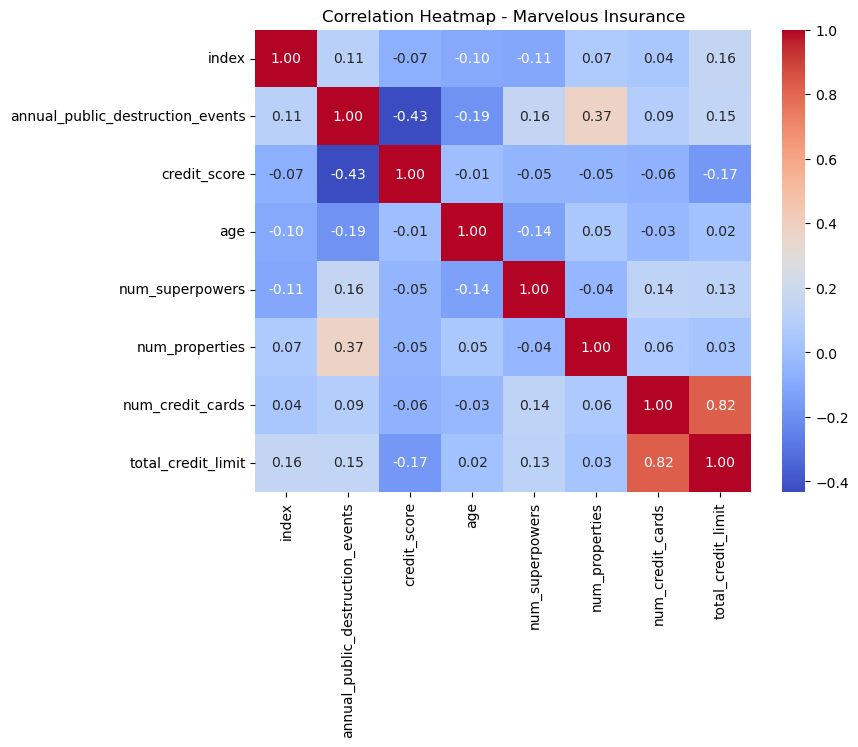

In [20]:
#Correlation heatmap

plt.figure(figsize=(8,6))
corr = df_model.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Marvelous Insurance")
plt.savefig("Correlation Heatmap")
plt.show()

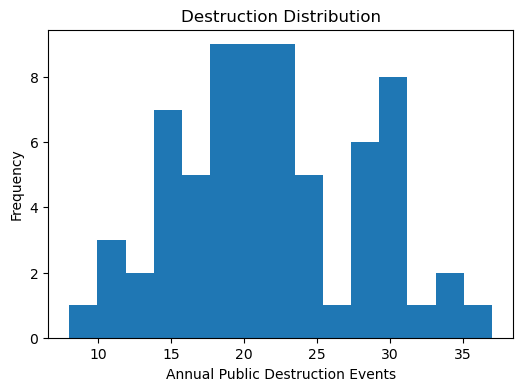

In [22]:
plt.figure(figsize=(6,4))

plt.hist(
    df_model["annual_public_destruction_events"],
    bins=15
)

plt.title("Destruction Distribution")
plt.xlabel("Annual Public Destruction Events")
plt.ylabel("Frequency")
plt.savefig("Destruction distribution")
plt.show()

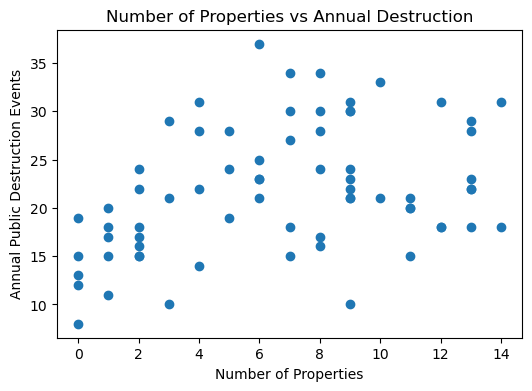

In [24]:
plt.figure(figsize=(6,4))

plt.scatter(
    df_model["num_properties"],
    df_model["annual_public_destruction_events"]
)

plt.title("Number of Properties vs Annual Destruction")
plt.xlabel("Number of Properties")
plt.ylabel("Annual Public Destruction Events")
plt.savefig("Scatterplot_Properties vs Destruction events")
plt.show()